# 构建知识库
RAG（Retrieval-Augmented Generation，检索增强生成）是LangChain的核心应用场景之一。它通过从外部知识库检索相关信息来增强LLM的回答质量。

一个完整的RAG流程分为两大部分：
- 知识库构建：加载文档 → 切分文本 → 向量化 → 存入向量库
- 检索生成：用户提问 → 向量化 → 检索相关文档 → 拼接上下文 → 生成回答

本章聚焦《知识库构建》部分。

知识库构建的完整流程如图：
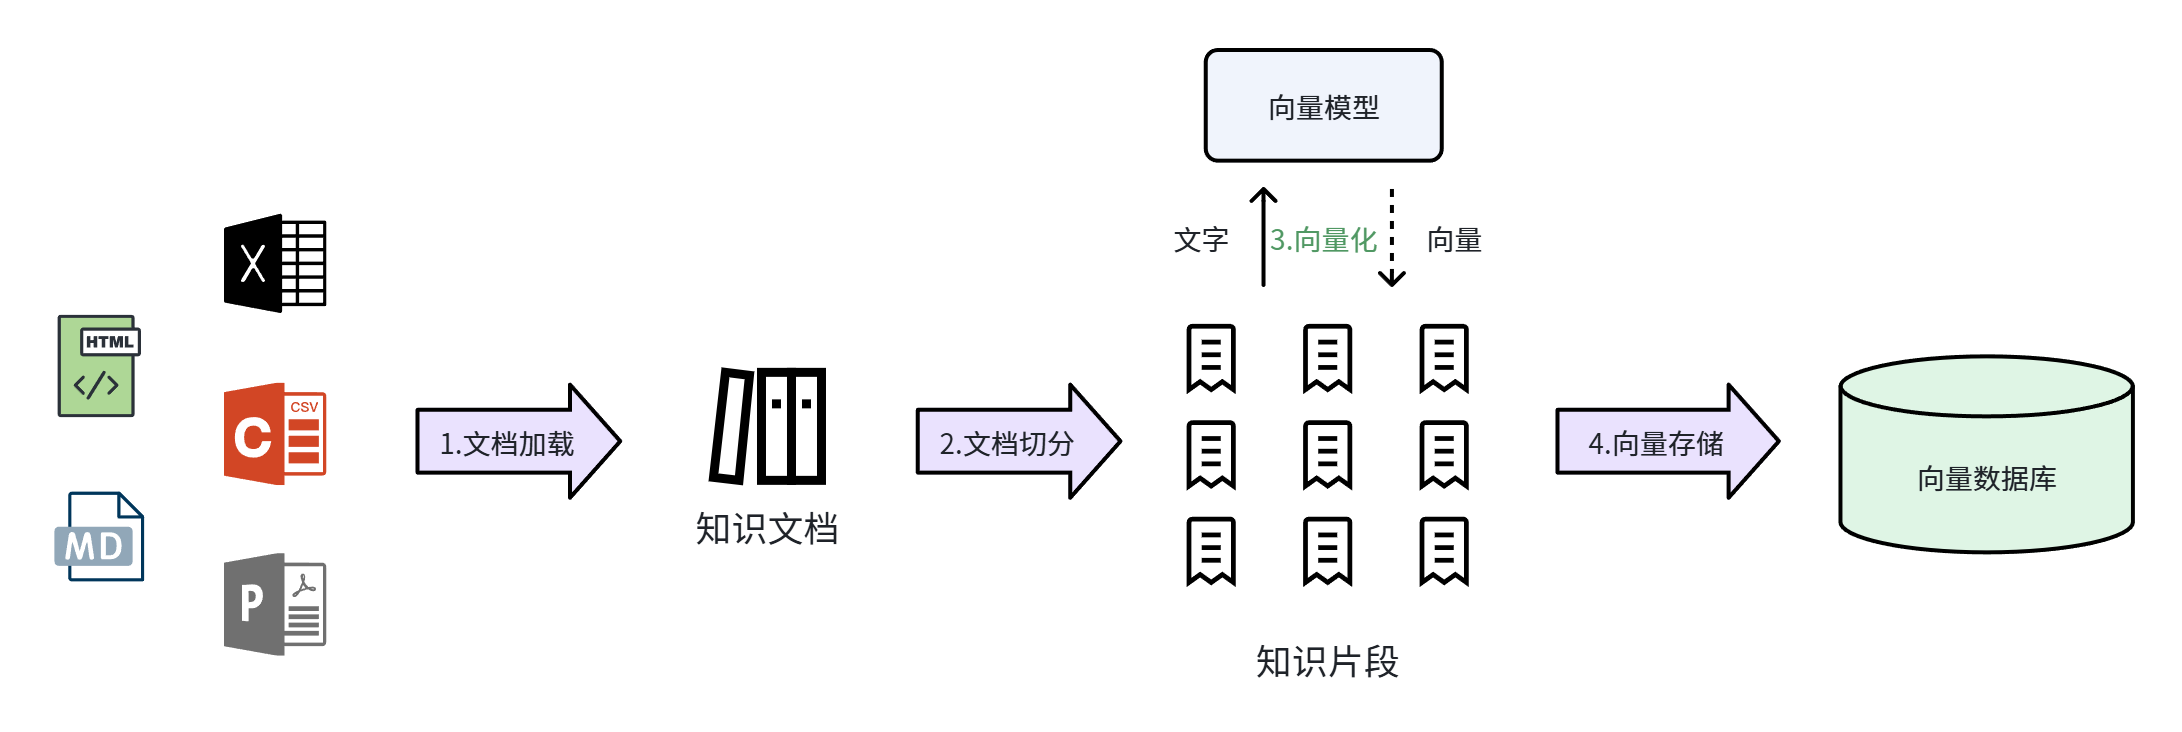

## 1. 文档加载（Document Loaders）
企业真实业务场景中，需要加载的文档类型多种多样，例如：
- PDF
- Word
- Text
- CSV
- Html
- ...

这些不同来源的数据格式、文档结构存在很大的差异，更离谱的是PDF文档中还有很多的扫描件。而RAG系统更擅长的是处理普通文本，因此不管是哪种文档来源，都需要经过处理变成普通文本才能存入向量库。

但是，如此多不同种类的文档，我们该如何处理呢？

LangChain提供了丰富的文档加载器（Document Loaders），支持从各种来源加载文档，例如：
- Webpages: 将网页内容加载为Document，例如WebBaseLoader
- PDFs: 将PDF文件加载为Document，例如PyPDF
- CommonFiles: 各种常见文件类型加载为Document，例如TextLoader、CSVLoader
- Social platforms: 从社交媒体加载文档，例如Twitter、Reddit
- Messaging services: 从消息平台加载文档，例如Telegram、WhatsApp、Discord
- Productivity tools: 从常用的生产力工具中加载文档，例如Figma、Github、Slack
更多文档加载器参考LangChain官网：https://docs.langchain.com/oss/python/integrations/document_loaders#all-document-loaders


虽然加载器各不相同，但都实现了BaseLoader接口，因此都具有两个通用方法：
- load() : 一次性加载所有文档
- lazy_load() : 基于流式传输懒加载文档，适用于大数据集
所有加载器都将原始数据转换为统一的 Document 对象，包含：
- page_content: 文档内容
- metadata: 元数据（如来源、页码等）
接下来，我们就看几个比较常见的加载器。

### 1.1 TextLoader
TextLoader是社区提供的加载器，作用是加载普通的txt文件，这也是最常见的一种文本文件类型，格式简单，没什么好说的，直接看代码。
示例代码：

In [ ]:
from langchain_community.document_loaders import TextLoader

# 创建示例文本文件
with open("resources/sample.txt", "w", encoding="utf-8") as f:
    f.write("LangChain是用于构建LLM应用的框架。\n")
    f.write("LangGraph是LangChain的图结构编排库。\n")
    f.write("LangSmith是调试监控平台。\n")

# 加载文本文件
loader = TextLoader("resources/sample.txt", encoding="utf-8")
docs = loader.load()

print(f"加载了 {len(docs)} 个文档")
print(f"内容: {docs[0].page_content}")
print(f"元数据: {docs[0].metadata}")

### 1.2 WebBaseLoader
WebBaseLoader同样是社区提供的加载器，只要给一个url地址，它就能自动读取网页内容，去掉无用的Html、CSS、JS元素，只保留普通文本数据。
示例：

In [3]:
from langchain_community.document_loaders import WebBaseLoader

# 加载网页内容
loader = WebBaseLoader(
    web_paths=["https://docs.langchain.com/oss/python/langchain/rag"],
)
docs = loader.load()

print(f"加载了 {len(docs)} 个文档")
print(f"来源: {docs[0].metadata.get('source', 'unknown')}")
print(f"内容长度: {len(docs[0].page_content)} 字符")
print(f"内容预览: {docs[0].page_content[:200]}...")

USER_AGENT environment variable not set, consider setting it to identify your requests.


加载了 1 个文档
来源: https://docs.langchain.com/oss/python/langchain/rag
内容长度: 34797 字符
内容预览: Build a RAG agent with LangChain - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip t...


### 1.3 CSVLoader
CSVLoader也是社区提供的加载器，它可以加载csv格式的文件，示例代码：

In [4]:
from langchain_community.document_loaders.csv_loader import CSVLoader

# 创建示例CSV文件
import csv
with open("resources/sample.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["name", "description", "category"])
    writer.writerow(["LangChain", "LLM应用开发框架", "AI框架"])
    writer.writerow(["LangGraph", "图结构编排库", "AI框架"])
    writer.writerow(["LangSmith", "调试监控平台", "AI工具"])

# 加载CSV文件
loader = CSVLoader(
    file_path="resources/sample.csv",
    source_column="name",  # 用name列作为source
    encoding="utf-8"
)
docs = loader.load()

print(f"加载了 {len(docs)} 行数据")
for doc in docs:
    print(f"  [{doc.metadata.get('source', '?')}] {doc.page_content[:100]}")

加载了 3 行数据
  [LangChain] name: LangChain
description: LLM应用开发框架
category: AI框架
  [LangGraph] name: LangGraph
description: 图结构编排库
category: AI框架
  [LangSmith] name: LangSmith
description: 调试监控平台
category: AI工具


### 1.4 yPDFLoader
PyPDFLoader顾名思义，是加载PDF文件的加载器，依赖于pypdf，所以需要先安装：
```bash
uv add pypdf
```
PyPDFLoader支持两种模式：
- single：整个文档作为一个Document，但是可以自定义文档页与页之间的分隔符
- page：每页作为一个Document

In [5]:
from langchain_community.document_loaders import PyPDFLoader

# 加载PDF文件（每页作为一个Document）
loader = PyPDFLoader(
    "resources/sample.pdf",
    mode="single", # single \ page
    pages_delimiter="\n-------THIS IS A CUSTOM END OF PAGE-------\n" # 自定义页分隔符，可选
)
docs = loader.load()

print(f"加载了 {len(docs)} 页")
print("-"*50)
print(f"第1页内容: {docs[0].page_content[:15800]}...")
print("-"*50)
print(f"元数据: {docs[0].metadata}")  # 包含 source, page 等信息

加载了 1 页
--------------------------------------------------
第1页内容: Sample PDFThis is a simple PDF ﬁle. Fun fun fun.
Lorem ipsum dolor sit amet, consectetuer adipiscing elit. Phasellus facilisis odio sed mi. 
Curabitur suscipit. Nullam vel nisi. Etiam semper ipsum ut lectus. Proin aliquam, erat eget 
pharetra commodo, eros mi condimentum quam, sed commodo justo quam ut velit. 
Integer a erat. Cras laoreet ligula cursus enim. Aenean scelerisque velit et tellus. 
Vestibulum dictum aliquet sem. Nulla facilisi. Vestibulum accumsan ante vitae elit. Nulla 
erat dolor, blandit in, rutrum quis, semper pulvinar, enim. Nullam varius congue risus. 
Vivamus sollicitudin, metus ut interdum eleifend, nisi tellus pellentesque elit, tristique 
accumsan eros quam et risus. Suspendisse libero odio, mattis sit amet, aliquet eget, 
hendrerit vel, nulla. Sed vitae augue. Aliquam erat volutpat. Aliquam feugiat vulputate nisl. 
Suspendisse quis nulla pretium ante pretium mollis. Proin velit ligula, sagittis at

### 1.5 复杂文本加载工具
某些行业的PDF文件结构非常复杂，可能包含：左右分栏、复杂表格、图文混排、图片扫描件等情况。
针对这样的PDF文件就需要用到诸如：文档结构识别模型、多模态模型、表格处理、OCR等专用工具，非常复杂。
好在市面上已经有很多专业的工具，帮我们实现了这些功能。

#### 1.5.1 PDF处理高级工具

常见的复杂PDF处理工具有：

| 维度 | Docling (IBM) | Marker | MinerU (上海AI实验室) | Unstructured |
| --- | --- | --- | --- | --- |
| 核心定位 | 企业级多格式文档处理与AI集成平台 | 轻量、快速的PDF/图像转Markdown工具 | 高精度中文及复杂文档解析专家 | 非结构化数据的通用ETL预处理平台 |
| 开发背景 | IBM苏黎世研究院，现为Linux基金会项目 | 个人开发者Vik Paruchuri创建，后获商业支持 | 上海人工智能实验室 (OpenDataLab) | Unstructured Technologies Inc. (商业公司) |
| 开源协议 | MIT (极其宽松，商用友好) | GPL-3.0 / 商业授权 (商用受限) | Apache-2.0 (商用友好) | Apache-2.0 (核心库开源，高级功能闭源) |
| 多格式支持 | 极强。原生支持 PDF、Word、PPT、Excel、HTML、图片等 | 专注于 PDF 及部分图片 | 原生支持 PDF、Word、PPT、Excel、HTML、图片等 | 全能型。支持数十种文件格式（Epub, EML, Docx 等） |
| 公式识别 (LaTeX) | 支持（通过内置模型解析） | 极强。专门针对论文公式进行了大量黑盒优化 | 顶级。内置专门的公式识别模型，学术论文还原度极高 | 较弱，通常只做普通文本提取或依赖第三方 |
| 表格提取能力 | 优秀（采用 IBM 专门的 Table Transformer 模型） | 良好 | 极强。能精准识别复杂表格并转为 HTML/Markdown | 良好（但开源版本较基础，高级提取需付费 API） |
| 多栏/复杂排版 | 极强（对多栏阅读顺序的恢复非常精准） | 优秀（基于启发式规则和模型结合） | 极强。对双栏、多栏论文的去页眉页脚及版面分析极佳 | 良好（依赖分区模型，但在极端复杂排版下可能错序） |
| 性能与速度 | 综合性能均衡，一篇学术基准论文中表现最优（RAG准确率达94.1%） | 速度最快，在H100 GPU批处理模式下可达25页/秒，单页约0.6秒 | 处理速度较快，约为200页/分钟，私有化部署下200页文档解析需18秒 | 速度一般，但通过API和多种分割策略，可在速度与质量间权衡 |
| RAG 生态对接 | 原生深度集成 LangChain 和 LlamaIndex | 需要手动处理输出的 Markdown | 适合作为预处理流，生态对接需自行封装 | 管道（Pipeline）生态极其成熟，原生适配各种向量数据库 |

总结一下，对于商业友好的开源产品有三款：
- Docling
- MinerU
- Unstructured
这三款中，文档处理能力最强的有两个：
- Docling
- MinerU
而这两个里，MinerU是国人开发，不管是处理速度还是精度都非常优秀。推荐使用。

另外，需要说明的是，无论是MinerU还是Docling都是可以本地部署使用的，要追求最佳性能需要本地GPU加速、部署本地视觉模型、OCR、Cuda工具。对于数据隐私要求较高的用户，可以选择本地部署。

MinerU提供了公共的API服务、桌面客户端、SDK等工具，每天可以免费处理5000个不超过200页的文档，小于20页的文档则不限数量。如果对数据隐私要求不高，而且希望降低运维成本的企业非常友好。

接下来我们就以MinerU为例来看看这种高级工具的PDF处理能力。

#### 1.5.2 注册MinerU
MinerU的公共API服务提供两种模式：
- 🎯 精准解析 API — 需申请 Token，支持单文件/批量、表格/公式/多格式输出，限制页数<=200
- ⚡ Agent 轻量解析 API — 免登录，IP 限频防滥用，专为 AI Agent 工作流设计，限制页数<=20
如果要使用精准解析模式，就必须注册账号，开通API Token，不过不用担心，并不需要收费~嘿嘿

注册地址：https://mineru.net/

#### 1.5.3 使用MinerU
MinerU的API是基于Http协议，理论上我们可以直接基于Http请求调用。不过，这样做太麻烦了。

MinerU还提供了多种不同的访问API接口的方式，例如：
- 基于Skills和MCP
- 基于CLI
- 基于SDK，支持Python、JS、TS、GO
- 基于RAG框架，支持LangChain、Dify、RAGFlow、LlamaIndex等
- ...
详见官方文档：https://mineru.net/ecosystem?tab=cli

这里重点说两种：
- SDK : 原生SDK，兼容性最好，可以自由的处理MinerU解析好的markdown、images、json
- LangChain : 完美适配LangChain，但解析PDF时只能得到markdown，其它内容无法获取
MinerU的其它用法可以参考官方教学文档：[03课：MinerU 在线 API 实战教程](https://aicarrier.feishu.cn/wiki/GtAmwcXKWivnGRk4nghcXaiNnrg)

MinerU的本地部署可以参考官方教学文档：[02课：MinerU 多环境部署实践：从开源容器化到信创生态适配](https://aicarrier.feishu.cn/wiki/B8EpwqoGyi2RpbkYIZGcRdJ6nng)

##### 1.5.3.1 基于SDK
首先来说SDK方式，我们先安装依赖：
```bash
uv add mineru-kie-sdk
```
然后就可以使用了：

In [ ]:
from mineru import MinerU
import os

# Flash 模式，无需Token
# 创建客户端
client = MinerU()
# 解析文件
result = client.flash_extract("./resources/sample.pdf")
# 输出到本地
result.save_markdown("./resources/output/r1.md")

In [ ]:
from dotenv import load_dotenv
load_dotenv()

# Precision模式，需要Token ，可以到官网申请 https://mineru.net
# 创建客户端
client = MinerU(os.getenv("MINERU_TOKEN"))
# 解析文件，支持各种自定义参数，例如：language、ocr、
result = client.extract("https://cdn-mineru.openxlab.org.cn/demo/example.pdf")
# 输出到本地
result.save_markdown("./resources/output/r2.md", True)

#### 1.5.3.2 基于LangChain
基于SDK方式虽然可以读取到图片，但输出格式只是普通文本。如果你的项目是基于LangChain，后续就需要我们自己把markdown封装为LangChain的Document.

所以，如果你的PDF不包含图片，或者图片中不包含重要信息，完全可以直接使用MinerU官方提供的LangChain版本SDK，解析完成后直接得到LangChain的Document对象。

首先，同样是安装依赖：

```bash
uv add langchain-mineru
```
接着，需要将MinerU的API Token配置到你的.env文件，key必须是 MINERU_TOKEN:

```
MINERU_TOKEN=M1MTIifQ.exxxx    
```
然后就可以用代码调用了：

In [ ]:
from langchain_mineru import MinerULoader

# 初始化客户端
loader = MinerULoader(
    source="./resources/贵州茅台研报.pdf",
    mode="flash" # 可选: flash 、 precision
)
# 解析文档，返回值直接是LangChain的 Document集合
docs = loader.load()

print(docs[0].metadata) # 元数据
# print(docs[0].page_content) # 文档内容

# 写到本地看看
with open("./resources/output/r5.md", "w", encoding="utf-8") as f:
    f.write(docs[0].page_content)

##### 1.5.3.3 OCR功能
对于扫描件类型的PDF，MinerU处理起来也毫不费力，只需要把OCR参数改为True即可：

In [ ]:
from langchain_mineru import MinerULoader

# 初始化客户端
loader = MinerULoader(
    source="./resources/small_ocr.pdf",
    mode="precision",
    ocr= True
)
# 解析文档，返回值直接是LangChain的 Document集合
docs = loader.load()

print(docs[0].metadata) # 元数据
print(docs[0].page_content) # 文档内容

# 写到本地看看
with open("./resources/output/r6.md", "w", encoding="utf-8") as f:
    f.write(docs[0].page_content)

MinerU不仅处理PDF是一把好手，它也能处理Html、ppt、pptx、doc、docx、xls、xlsx、图片等多种格式，理论上有这一种加载器就能满足90%的企业需求了。

## 2. 文本切分（Text Splitters）
LLM的上下文窗口有限，不能将加载的整个文档扔进去，需要将文档切分成合适大小的块（chunk）。

但是到底该切多大呢？

这可不能随意，因为切分大小会直接影响检索质量：
- 太大: 包含过多无关信息，检索精度下降
- 太小: 丢失上下文，语义不完整

那么，该如何切分出合适大小的chunk呢？

常见的文档切分策略如下：

| 策略名称 | 核心原理 | ✅ 优点 | ❌ 缺点 | 适用场景 |
| --- | --- | --- | --- | --- |
| 固定长度切分 | 按预设字符数或Token数切分 | 实现简单，速度快，可预测。 | 易在句子中间截断，严重破坏语义完整性。 | 日志、代码等结构不敏感文本；或作为性能基线。 |
| 递归切分 | 按优先级分隔符（如段落\n\n > 句子。）逐级递归分割，直至满足大小要求。 | 尊重文档结构，语义完整性好，能动态调整。 | 对无标准分隔符的文本效果下降。 | 通用首选，适用于报告、文章等大多数规范文档。 |
| 语义切分 | 用嵌入模型计算相邻句子相似度，在低于阈值时切分，识别主题转折点。 | 最大限度保持语义连贯性，分块质量高。 | 计算成本高，依赖嵌入模型精度。 | 对语义完整性要求极高的场景，如学术论文、法律文件。 |
| 结构感知切分 | 利用文档元数据（如Markdown/HTML标题）识别逻辑区块进行切分。 | 天然符合文档组织逻辑，结构清晰准确。 | 需要格式良好的文档，灵活性受限。 | Markdown、网页等有清晰原生结构的文档。 |
| 滑动窗口切分 | 固定窗口，通过高重叠率（如20%）滑动生成连续分块，保留上下文。 | 上下文连接紧密，避免信息断裂。 | 冗余度高，存储和计算开销大。 | 可以与其它策略结合 |

LangChain对常见的切分策略都有支持，并且提供了统一的接口：TextSplitter，

### 2.1 固定长度切分
先看最简单的一种，就是固定长度切分，在LangChain里提供了两个实现：
- 根据字符大小切分
- 根据字节大小切分
不管哪种都需要用到CharacterTextSplitter这个类。


#### 2.1.1 CharacterTextSplitter - 按字符切分
最简单的切分方式，属于固定长度切分策略的一种，常见的三个参数：
- separator : 分隔符，以此作为分隔的基本单元
- chunk_size : 块大小，如果超出则放到下个块
- chunk_overlap : 下一块与上一块重叠的大小，也就是滑动窗口切分

In [13]:
from langchain_text_splitters import CharacterTextSplitter

# 准备一段较长的文本
long_text = docs[0].page_content

# 创建字符切分器
text_splitter = CharacterTextSplitter(
    separator="\n",    # 以换行符作为分隔
    chunk_size=1000,     # 每块最大1000字符
    chunk_overlap=200,   # 块之间重叠200字符
)


# 切分文本
chunks = text_splitter.split_text(long_text)

print(f"原始文本长度: {len(long_text)} 字符")
print(f"切分为 {len(chunks)} 个块:\n")
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk)}字符) ---")
    print(chunk)
    print()

原始文本长度: 2876 字符
切分为 4 个块:

--- Chunk 1 (968字符) ---
Sample PDFThis is a simple PDF ﬁle. Fun fun fun.
Lorem ipsum dolor sit amet, consectetuer adipiscing elit. Phasellus facilisis odio sed mi. 
Curabitur suscipit. Nullam vel nisi. Etiam semper ipsum ut lectus. Proin aliquam, erat eget 
pharetra commodo, eros mi condimentum quam, sed commodo justo quam ut velit. 
Integer a erat. Cras laoreet ligula cursus enim. Aenean scelerisque velit et tellus. 
Vestibulum dictum aliquet sem. Nulla facilisi. Vestibulum accumsan ante vitae elit. Nulla 
erat dolor, blandit in, rutrum quis, semper pulvinar, enim. Nullam varius congue risus. 
Vivamus sollicitudin, metus ut interdum eleifend, nisi tellus pellentesque elit, tristique 
accumsan eros quam et risus. Suspendisse libero odio, mattis sit amet, aliquet eget, 
hendrerit vel, nulla. Sed vitae augue. Aliquam erat volutpat. Aliquam feugiat vulputate nisl. 
Suspendisse quis nulla pretium ante pretium mollis. Proin velit ligula, sagittis at, egestas a, 
p

#### 2.1.2 CharacterTextSplitter - 按Token切分
使用OpenAI开源的tiktoken计算token数量，按token数量切分，更精确地控制发送给LLM的token数。

In [14]:
from langchain_text_splitters import CharacterTextSplitter

# 使用from_tiktoken_encoder，LangChain自带，无需额外安装tiktoken
token_splitter = CharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",    # token分词器编码名
    chunk_size=1000,                # 每块最多1000 token
    chunk_overlap=200,              # 块之间重叠200字符
)

chunks = token_splitter.split_text(long_text)

print(f"原始文本长度: {len(long_text)} 字符")
print(f"切分为 {len(chunks)} 个块:\n")
for i, chunk in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(chunk)}字符) ---")
    print(chunk)
    print()

原始文本长度: 2876 字符
切分为 1 个块:

--- Chunk 1 (2876字符) ---
Sample PDFThis is a simple PDF ﬁle. Fun fun fun.
Lorem ipsum dolor sit amet, consectetuer adipiscing elit. Phasellus facilisis odio sed mi. 
Curabitur suscipit. Nullam vel nisi. Etiam semper ipsum ut lectus. Proin aliquam, erat eget 
pharetra commodo, eros mi condimentum quam, sed commodo justo quam ut velit. 
Integer a erat. Cras laoreet ligula cursus enim. Aenean scelerisque velit et tellus. 
Vestibulum dictum aliquet sem. Nulla facilisi. Vestibulum accumsan ante vitae elit. Nulla 
erat dolor, blandit in, rutrum quis, semper pulvinar, enim. Nullam varius congue risus. 
Vivamus sollicitudin, metus ut interdum eleifend, nisi tellus pellentesque elit, tristique 
accumsan eros quam et risus. Suspendisse libero odio, mattis sit amet, aliquet eget, 
hendrerit vel, nulla. Sed vitae augue. Aliquam erat volutpat. Aliquam feugiat vulputate nisl. 
Suspendisse quis nulla pretium ante pretium mollis. Proin velit ligula, sagittis at, egestas a, 


### 2.2 递归字符切分（推荐）
LangChain中提供了一个RecursiveCharacterTextSplitter类，实现了递归字符切分。

这是LangChain推荐的通用文本切分器，在不超过目标块大小的前提下，尽可能保持段落和句子的完整性。

关键参数如下：

| 参数 | 作用 | 默认值 (通常情况) |
| --- | --- | --- |
| chunk_size | 目标块大小 (以字符/token计)。分割器努力让每个块的文本长度不超过这个值。 | 4000 |
| chunk_overlap | 块间重叠长度。为了让块与块之间保留一些共同上下文，避免在关键信息处被切断。 | 200 |
| separators | 自定义分隔符优先级列表。这是控制分割行为的核心，你可以根据文档格式（如代码、Markdown）调整顺序。 | ["\n\n", "\n", " ", ""] |
| length_function | 长度计算函数。决定用何种方式测量文本长度（例如 len 计字符数，或 tiktoken 计token数）。 | len |

其切割流程如下：
1. 输入：原始长文本 T，目标块大小 size，一个有序的字符列表 separators (例如：["\n\n", "\n", "。", " ", ""]，优先级从高到低)。
2. 第一步（用最高级分隔符尝试）：使用当前优先级最高的分隔符（例如段落分隔符 \n\n）尝试将 T 分割成若干块。
3. 检查与判断：
  - 遍历刚分割出的每一个块。
  - 如果这个块的长度小于等于 chunk_size，则将其保留为一个最终的文本块。
  - 如果这个块的长度大于 chunk_size，则不能接受它。
4. 递归降级：对于所有大于 chunk_size 的“超大块”，放弃使用当前分隔符，改用下一个优先级更低的分隔符（例如换行符 \n）来对这个“超大块”再次进行分割。
5. 重复：重复第 3 步和第 4 步，直到所有块都小于等于 chunk_size。
6. 最终手段：如果尝试了所有分隔符，仍然有块大于 chunk_size，那么它会在最后一级分隔符（通常是空字符串 ""，即按字符切分）上，强制将文本按 chunk_size 的长度进行硬截断。

In [15]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

# 创建递归切分器
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=2000,
    chunk_overlap=200,
    separators=["\n\n", "\n", "。"]  # 优先级从高到低
)

# 切分文档
chunks = recursive_splitter.split_documents(docs)

print(f"切分为 {len(chunks)} 个块:\n")
for i, split in enumerate(chunks):
    print(f"--- Chunk {i+1} ({len(split.page_content)}字符) ---")
    print(split.page_content)
    print()

切分为 2 个块:

--- Chunk 1 (1989字符) ---
Sample PDFThis is a simple PDF ﬁle. Fun fun fun.
Lorem ipsum dolor sit amet, consectetuer adipiscing elit. Phasellus facilisis odio sed mi. 
Curabitur suscipit. Nullam vel nisi. Etiam semper ipsum ut lectus. Proin aliquam, erat eget 
pharetra commodo, eros mi condimentum quam, sed commodo justo quam ut velit. 
Integer a erat. Cras laoreet ligula cursus enim. Aenean scelerisque velit et tellus. 
Vestibulum dictum aliquet sem. Nulla facilisi. Vestibulum accumsan ante vitae elit. Nulla 
erat dolor, blandit in, rutrum quis, semper pulvinar, enim. Nullam varius congue risus. 
Vivamus sollicitudin, metus ut interdum eleifend, nisi tellus pellentesque elit, tristique 
accumsan eros quam et risus. Suspendisse libero odio, mattis sit amet, aliquet eget, 
hendrerit vel, nulla. Sed vitae augue. Aliquam erat volutpat. Aliquam feugiat vulputate nisl. 
Suspendisse quis nulla pretium ante pretium mollis. Proin velit ligula, sagittis at, egestas a, 
pulvinar quis, n

### 2.3 结构感知切分
利用文档元数据识别文档本身的逻辑区块进行切分。

例如：markdown中的多级标题、JSON结构中的字段、Html中的标签等等。

LangChain都提供了对应不同文档类型的结构感知切分器，例如：
- MarkdownHeaderTextSplitter
- RecursiveJsonSplitter
- HTMLHeaderTextSplitter
- RecursiveCharacterTextSplitter.from_language()
- ...
此处，我们以markdown为例来演示。

例如，一段markdown文本如下：

```
# 1.Foo

## 1.1.Bar
Hi this is Jim
Hi this is Joe

### 1.1.1.Boo
Hi this is Lance

## 1.2.Baz
Hi this is Molly
```

In [16]:
from langchain_text_splitters import MarkdownHeaderTextSplitter

# markdown数据
markdown_document = "# 1.Foo\n\n    ## 1.1.Bar\n\nHi this is Jim\n\nHi this is Joe\n\n ### 1.1.1.Boo \n\n Hi this is Lance \n\n ## 1.2.Baz\n\n Hi this is Molly"

# 切分依据，这里是按照三级标题
headers_to_split_on = [
    ("#", "Header 1"),
    ("##", "Header 2"),
    ("###", "Header 3"),
]

# 创建切分器
markdown_splitter = MarkdownHeaderTextSplitter(headers_to_split_on)

# 切分文档
chunks = markdown_splitter.split_text(markdown_document )

for doc in chunks:
    print(doc.model_dump_json(indent=2))

{
  "id": null,
  "metadata": {
    "Header 1": "1.Foo",
    "Header 2": "1.1.Bar"
  },
  "page_content": "Hi this is Jim  \nHi this is Joe",
  "type": "Document"
}
{
  "id": null,
  "metadata": {
    "Header 1": "1.Foo",
    "Header 2": "1.1.Bar",
    "Header 3": "1.1.1.Boo"
  },
  "page_content": "Hi this is Lance",
  "type": "Document"
}
{
  "id": null,
  "metadata": {
    "Header 1": "1.Foo",
    "Header 2": "1.2.Baz"
  },
  "page_content": "Hi this is Molly",
  "type": "Document"
}


### 2.4 总结
没有绝对正确的文档切分方式，一定要根据具体文档来具体判断。

如果你采用了MinerU这样的文本加载器，由于其输出的格式通常是Markdown，有严谨的文档结构，那我的建议切分方式是：
- 优先采用Markdown的文档结构切分，不仅语义完整度高，而且还能记住自己所处的章节
- 当基于文档结构切分的块太大时，可以对超过目标size的块采用递归字符切分，但要保留header到每一个分块

## 3. 向量化（Embeddings）
文档切分成块后，下一步就是把文本向量化了。

向量化是将文本转换为高维向量的过程。语义相似的文本在向量空间中距离更近，这是语义检索的基础。
目前比较常见的小规模、开源文本向量模型有：
| 模型 | 参数量 | 维度 | 最大长度 | 核心特点 |
| --- | --- | --- | --- | --- |
| Qwen3-Embedding-0.6B | 0.6B | 1024 | 32K | MTEB多语言榜64.34分，支持MRL维度压缩，多语言能力强 |
| jina-code-embeddings-0.5B | 0.5B | 896 | 32K | 代码检索SOTA，MTEB Code平均78.72%，支持15+编程语言，Last-token池化 |
| jina-embeddings-v5-omni-nano | ~1.0B | 768 | 8K | 全模态(文本/图像/音频/视频/PDF)，冻结底座仅训练0.35%参数，支持MRL维度压缩 |
| jina-embeddings-v5-omni-small | ~1.6B | 1024 | 32K | 全模态四模态平均53.93分，文本侧与v5-text逐字节兼容，MMTEB文本67.0分 |
| jina-code-embeddings-1.5B | 1.5B | 1536 | 32K | 代码检索AVG 79.04%，匹配voyage-code-3闭源模型，支持GGUF量化 |
| BGE-M3 | 0.56B | 1024 | 8K | 支持稠密+稀疏+多向量混合检索，MIT协议，多语言表现优异 |
| all-MiniLM-L6-v2 | ~0.08B | 384 | 512 | 纯英文优化，仅80M参数，推理速度比12层快50%，STS英文表现优 |

还有一些参数规模大一点的向量模型，性能更强：

| 模型名称 | 开发方 | 参数量 | 维度 | 最大长度 | 权威基准表现 (MTEB) | 核心特点与适用场景 |
| --- | --- | --- | --- | --- | --- | --- |
| Llama-Embed-Nemotron-8B | NVIDIA | 8B | 4096 | 32K | MMTEB 排名第 1 (截至2025.10) | 当前的性能之王。基于Llama-3.1-8B，采用了创新的注意力池化机制，在多语言和跨语言任务上表现极佳。 |
| Qwen3-Embedding-8B | 阿里通义 | 8B | 4096 | 32K | MMTEB 排名第 3 (70.58分) | 综合性能极强，紧随NVIDIA之后，是目前开源社区最流行、最成熟的顶级模型之一。 |
| C2LLM-7B | 蚂蚁集团 & 上海交大 | 7B | - | - | MTEB-Code榜单第 1 (80.75分) | 代码检索专用，专为代码理解和检索设计，号称“代码检索新王”。 |
| gte-Qwen2-7B-instruct | 阿里达摩院 | 7B | 3584 | 8K | 优秀 (62.51分) | 阿里上一个世代的代表作，性能依然强劲且成熟稳定。 |
| Gemini Embedding 2 | Google DeepMind | 未公开 | - | - | MMTEB 69.9分 (纯文本) | 谷歌官方多模态王牌。原生支持文本、图像、视频、音频的统一向量化，多模态检索能力最强。 |
| OpenAI text-embedding-3-large | OpenAI | - | 3072 | 8K | MTEB约64.8分 | 商业API首选，性能强大且稳定，按量付费，适合不想自己部署、追求省心的团队。 |

其中的开源模型我们可以本地部署，也可以使用模型平台提供的服务。

LangChain支持多种Embedding模型平台，可以自由选择：
| 模型 | 提供方 |
| --- | --- |
| OpenAIEmbeddings | OpenAI |
| DashScopeEmbeddings | 阿里云百炼 |
| HuggingFaceEmbeddings | 本地开源模型 |
| OllamaEmbeddings | 本地开源模型 |

更多LangChain支持的向量模型参考官方文档：https://docs.langchain.com/oss/python/integrations/embeddings

### 3.1 Ollama Embeddings
我们先演示下ollama的向量模型。

注意，ollama只是工具，关键是你基于ollama部署的模型是什么，这一点与Huggingface是类似的。
比如，我们采用阿里提供的qwen3-embedding:0.6b这个模型，它在小模型中算是效果比较好的一个，不管是Huggingface还是Ollama都支持下载和部署这个模型。

首先需要安装依赖：
```bash
 uv add langchain-ollama
```
然后就可以使用了：

In [ ]:
from langchain_ollama import OllamaEmbeddings

# 创建Embedding模型
ollama_embeddings = OllamaEmbeddings(
    model="qwen3-embedding:0.6b",  # 性价比高的模型
    dimensions=1024  # 可选：减少维度以节省存储
)

# 向量化单条文本
text = "我爱上班"
vector = ollama_embeddings.embed_query(text)

print(f"文本: {text}")
print(f"向量维度: {len(vector)}")
print(f"向量前5维: {vector[:5]}")

# 批量向量化
texts = ["我要躺平", "我爱工作", "拒绝加班"]
vectors = ollama_embeddings.embed_documents(texts)
print(f"\n批量向量化: {len(vectors)} 条, 维度: {len(vectors[0])}")

我们自定义一个计算余弦相似度的函数，测试下：

In [18]:
import numpy as np

def cosine_similarity(vec1, vec2):
    dot = np.dot(vec1, vec2)
    return dot / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

# 比较向量相似度，值越小越相似
for v in vectors:
    similarity = cosine_similarity(vector, v)
    print("Cosine Similarity:", similarity)

Cosine Similarity: 0.5254144258464633
Cosine Similarity: 0.9159621493477776
Cosine Similarity: 0.6147298238032792


### 3.2 DashScope Embeddings（阿里云百炼）
阿里云百炼平台也提供了很多文本向量化模型，比如qwen的text-embedding-v3、text-embedding-v4模型。只要注册并配置了阿里云保留的API_KEY，就都能使用。

In [19]:
# 使用阿里云百炼的Embedding服务
from langchain_community.embeddings import DashScopeEmbeddings
import os

dashscope_embeddings = DashScopeEmbeddings(
    model="text-embedding-v3",
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY")
)

# 向量化单条文本
text = "我爱上班"
vector = dashscope_embeddings.embed_query(text)

print(f"文本: {text}")
print(f"向量维度: {len(vector)}")
print(f"向量前5维: {vector[:5]}")

# 批量向量化
texts = ["我要躺平", "我爱工作", "拒绝加班"]
vectors = dashscope_embeddings.embed_documents(texts)
print(f"\n批量向量化: {len(vectors)} 条, 维度: {len(vectors[0])}")

for v in vectors:
    similarity = cosine_similarity(vector, v)
    print("Cosine Similarity:", similarity)

文本: 我爱上班
向量维度: 1024
向量前5维: [-0.08089112490415573, 0.0366407111287117, -0.08781595528125763, 0.01530501153320074, -0.034509994089603424]

批量向量化: 3 条, 维度: 1024
Cosine Similarity: 0.5254144258464633
Cosine Similarity: 0.9159621493477776
Cosine Similarity: 0.6147298238032792


## 4. 向量库（Vector Stores）
向量库用于存储和检索向量化后的文档。LangChain支持多种向量库：
| 向量库 | 特点 | 适用场景 |
| --- | --- | --- |
| InMemoryVectorStore | 内存存储，零配置 | 开发测试 |
| Chroma | 轻量级，支持持久化 | 中小规模 |
| FAISS | 高性能，支持GPU | 大规模检索 |
| Milvus | 高性能，支持GPU | 大规模检索 |

更多支持的向量库参考LangChain官方文档：https://docs.langchain.com/oss/python/integrations/vectorstores

LangChain提供了统一的VectorStore接口，使你可以用统一的方式调用任意向量库：
- add_documents: 添加文档到向量库（不用自己做文本向量化，只要提供好向量模型即可）
- delete: 根据id删除某个文档
- similarity_search: 基于相似度检索与用户问题有关的文档

### 4.1 初始化向量库-Chroma

Chroma支持将向量数据持久化到磁盘，适合中小规模应用。
首先，需要安装LangChain的Chroma库：
uv add langchain-chroma
接着，就可以创建Chroma库了，需要指定在本地存储的文件路径：

In [21]:
from langchain_chroma import Chroma

# 创建向量库
vectorstore = Chroma(
    collection_name="example_collection",
    embedding_function=dashscope_embeddings,
    persist_directory="./db/chroma_langchain_db",
)

### 4.2 添加/删除文档
添加和删除方法：
- add_documents：接收list[Document]，可以批量添加文档
- delete：接收list[str]，也就是id集合，可以根据id批量删除文档

In [ ]:
# 准备文档，我们用之前读取的Markdown文档来测试
with open("./resources/output/r5.md", encoding="utf-8") as f:
    markdown_text = "\n".join(line for line in f.readlines())

# 用递归切分器切分文档
chunks = recursive_splitter.split_documents(
    [Document(page_content=markdown_text, metadata={"filename": "r5.md"})]
)
# 给文档生成id
ids=[]
for i,c in enumerate(chunks):
    c.id = f"doc_{i+1}"
    c.metadata['id'] = c.id
    ids.append(c.id)
# 删除旧文档
vectorstore.delete(ids)
# 添加新文档
vectorstore.add_documents(chunks)

### 4.3 检索文档
VectorStore提供了多个检索文档的方法，例如：
- search: 通用搜索方法，支持最多样化的参数
- similarity_search: 基于相似度的搜索
- similarity_search_with_relevance_scores: 基于相似度搜索，并且会返回相似度得分
- ...

我们先看search方法。

search方法实现文档检索，其核心参数包括：
- query: 查询条件
- search_type: 查询类型，有3个可选值，
  - similarity:相似度检索，等同于similarity_search
  - similarity_score_threshold:会基于相似度分数阈值做过滤的检索，底层是similarity_search_with_relevance_scores，但不返回得分
  - mmr:先基于相似度检索，再把结果基于mmr算法筛选，提升结果的多样性
其它参数(并不是所有向量库都支持):
- k: 要返回的文档数量（默认值：4）
- score_threshold: similarity_score的最小关联阈值，低于这个分值的文档会被丢弃
- fetch_k: 传递给MMR算法的文档数量（默认：20）
- lambda_mult: MMR返回结果的多样性；1表示最小分集，0表示最大分集。(默认值:0.5)
- filter: 按文档元数据（metadata）筛选

#### 4.3.1 相似度检索
先来演示search方法，只返回文档，没有得分：

In [ ]:
# 用户问题
query = "茅台2025年的市盈率和市净率分别是多少"
# 相似度检索
results = vectorstore.search(
    query=query,
    search_type="similarity",
    k = 5,
)

print(f"查询: {query}\n")
for i, doc in enumerate(results):
    print(f"结果 {i+1}: {doc.page_content}")
    print(f"  元数据: {doc.metadata}")

#### 4.3.2 基于metadata过滤
我们还可以在检索时基于文档的metadata做过滤：

In [ ]:
# 用户问题
query = "茅台2025年的市盈率和市净率分别是多少"
# 相似度检索
results = vectorstore.search(
    query=query,
    search_type="similarity",
    k = 5,
    filter={"id": "doc_3"}
)

print(f"查询: {query}\n")
for i, doc in enumerate(results):
    print(f"结果 {i+1}: {doc.page_content}")
    print(f"  元数据: {doc.metadata}")

#### 4.3.3 带相似度得分的检索
如果调用VectorStore的similarity_search_with_score方法，还可以在检索时返回相似度打分：

In [ ]:
# 用户问题
query = "茅台2025年的市盈率和市净率分别是多少"
# 相似度检索
results = vectorstore.similarity_search_with_relevance_scores(
    query=query,
    # search_type="similarity_score_threshold", 不需要search_type了
    score_threshold=0.42,
    k = 5
)

print(f"查询: {query}\n")
for doc, score in results:
    print(f"======文档: {doc.id}，得分：{score}=======")
    print(f"内容: {doc.page_content}")
    print(f"元数据: {doc.metadata}")

### 4.4 Chroma - 轻量级持久化向量库
Chroma支持将向量数据持久化到磁盘，适合中小规模应用。
首先，需要安装LangChain的Chroma库：
uv add langchain-chroma
接着，就可以创建Chroma库了，需要指定在本地存储的文件路径：

In [ ]:
from langchain_chroma import Chroma

vectorstore = Chroma(
    collection_name="example_collection",
    embedding_function=ollama_embeddings,
    persist_directory="./db/chroma_langchain_db",
)

In [ ]:
# 用户问题
query = "茅台2025年的市盈率和市净率分别是多少"
# 相似度检索
results = vectorstore.similarity_search(
    query=query,       # 用户问题
    k = 5# 返回Top k
)

print(f"查询: {query}\n")
for i, doc in enumerate(results):
    print(f"结果 {i+1}: {doc.page_content}")
    print(f"  元数据: {doc.metadata}")

## 5. 检索器（Retriever）
检索器（Retriever）是一种接口，能够根据非结构化查询返回文档。它的功能比向量存储更通用。检索器不需要具备存储文档的能力，只需能够返回文档即可。

检索器可以由向量存储构建，也可以由其他数据源构建，因此使用范围更广。

检索器接受字符串形式的查询作为输入，并返回一个由文档对象组成的列表作为输出。

### 5.1 VectorStore转Retriever
需要注意的是，所有VectorStore都可以转换为检索器。

VectorStore提供as_retriever()方法将其转换为检索器，可以把调用VectorStore时的参数提前固化，简化后期的查询。

例如，每次我们都要传入k=3作为参数，我们就可以将其固化，转vectorstore为一个固定每次最多查3条数据的retriever：

In [ ]:
retriever = vectorstore.as_retriever(
    search_type="similarity",  # 检索类型: similarity, mmr, similarity_score_threshold
    search_kwargs={"k": 3}     # 返回top-3结果
)

当然，除了k以外，你也可以固化更多参数VectorStore支持的参数。但需要注意的是，Retirevers是不会返回得分的。

### 5.2 其它Retriever
其它只要能根据query查询文档的数据源都可以称为Retriever，当然需要LangChain支持才可以。

具体LangChain的支持列表参考官网：
https://docs.langchain.com/oss/python/integrations/retrievers

## 6. 总结

知识库构建核心组件：
| 组件 | 作用 | 常用选择 |
| --- | --- | --- |
| Document Loader | 加载原始文档 | MinerU, Docling |
| Text Splitter | 切分文档为chunk | RecursiveCharacterTextSplitter |
| Embeddings | 文本转向量 | DashScopeEmbeddings, BGE-M3, qwen3-embedding:0.6b |
| Vector Store | 存储和检索向量 | InMemory(开发), Chroma(中小), Milvus(大规模) |
| Retriever | 标准检索接口 | vectorstore.as_retriever() |

关键参数建议：
- chunk_size: 建议 200~1000，取决于文档类型和模型上下文长度
- chunk_overlap: 建议 chunk_size 的 10%~20%
- k (检索数量): 建议 3~10，太少可能遗漏，太多可能引入噪声